<a href="https://colab.research.google.com/github/Spatel1309/undergrad_ml_assignments/blob/main/05_assignment_glm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. We use general linear models/lantent variable models/activation functions in analysis because there are several limitations to linear models. First, linear prbability models can not interpret outcomes less than 0 or greater than 1. We like linear models can they are easy to interpret but have restrictions when it comes to the output. By using general linear models/latent variable models and passing them through activation functions, we do not run into these restrictions.

2. Binary and categorical cross-entropy are effective loss functions because they arise from the likelihood of Bernoulli models, making them the natural objective for logistic regression. They strongly penalize confident incorrect predictions and ensure optimal probability estimates.

3. True. Even though the output is a probability (non-linear ), but the model/parameters are linear

4. False. We convert the probability outputs into classes using a threshold (threshold is typically 0.5)

5. No, in a logistic regression, coefficients do not represent the change in predicted probability for a one-unit increase in a feature. Instead the coefficients represent changes in the log-odds, which the effect on probability is not constant.

6. False. The output is nonlinear, the model is linear. So feature engineering is necessary to capture nonlinear relationships

7. False. Logistic regression is not always better than linear regression. It is appropriate for binary outcomes, while linear regression is better for continuous/linear outcomes.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [ ]:
import pandas as pd
df = pd.read_csv("data.csv", sep=";")
cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]

df = df[cols]

print(df.isna().sum())

df = df.dropna()

df["Target_binary"] = df["Target"].apply(lambda x: 1 if x == "Dropout" else 0)

df.head()

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,Target_binary
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


We handled missing values by simipling removing any rows with missing values.

In [ ]:
from sklearn.linear_model import LogisticRegression

X = df[[
    "Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]

y = df["Target_binary"]

model = LogisticRegression()
model.fit(X, y)

coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_[0]
})

print(coef_df)

                  Variable  Coefficient
0                   Debtor     0.530625
1  Tuition fees up to date    -2.556542
2       Scholarship holder    -1.227442
3        Age at enrollment     0.049925


Debtor and Age at enrollment have positive coefficients, indicating a higher probability of dropout. Tuition fees up to date and Scholarship holder have negative coefficients, indicating a lower probability of dropout. Yes, being up to date on tuition reduces dropout risk.

In [ ]:
df["pred_prob"] = model.predict_proba(X)[:, 1]

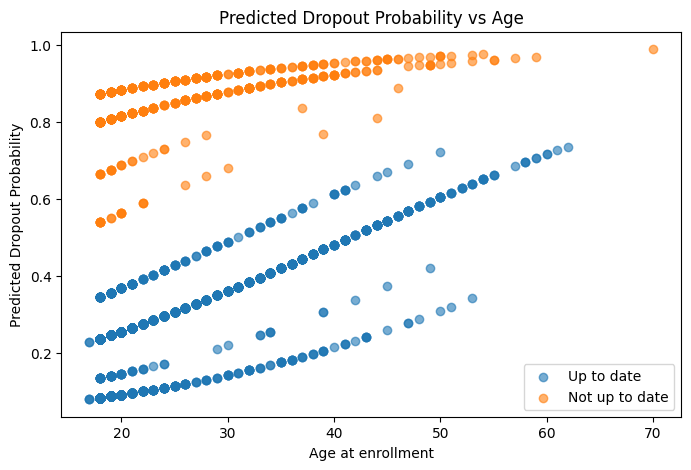

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Plot: Age vs predicted probability
for val in df["Tuition fees up to date"].unique():
    subset = df[df["Tuition fees up to date"] == val]
    label = "Up to date" if val == 1 else "Not up to date"

    plt.scatter(subset["Age at enrollment"], subset["pred_prob"], label=label, alpha=0.6)

plt.xlabel("Age at enrollment")
plt.ylabel("Predicted Dropout Probability")
plt.title("Predicted Dropout Probability vs Age")
plt.legend()
plt.show()

In [ ]:
X_up = X.copy()
X_not = X.copy()

X_up["Tuition fees up to date"] = 1
X_not["Tuition fees up to date"] = 0

p_up = model.predict_proba(X_up)[:, 1]
p_not = model.predict_proba(X_not)[:, 1]

df["tuition_effect"] = p_not - p_up

In [ ]:
avg_effect = df["tuition_effect"].mean()
print(avg_effect)

0.5161819741831828


In [ ]:
age_effect = df.groupby("Age at enrollment")["tuition_effect"].mean()
print(age_effect.sort_values(ascending=False).head())

Age at enrollment
22    0.537499
23    0.535802
21    0.535541
20    0.532669
24    0.531446
Name: tuition_effect, dtype: float64


From both the scatterplot and the values above, you can see that being up to date on tuition reduce dropout rate the most for people in their early 20s (20 to 24). On average, being up to date on tuition, reducing the probability of dropping out by about 0.516.

In [ ]:
import numpy as np

y_class = pd.Series(model.predict(X))

tab = pd.crosstab(y_class, y)

acc = np.trace(tab) / len(y_class)

print(f"Confusion matrix:\n{tab}")
print(f"\nAccuracy: {acc}")

Confusion matrix:
Target_binary     0    1
row_0                   
0              2841  891
1               162  530

Accuracy: 0.7619801084990958


In [ ]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)

df["linear_pred"] = lin_model.predict(X)

In [ ]:
df["log_pred"] = model.predict_proba(X)[:,1]

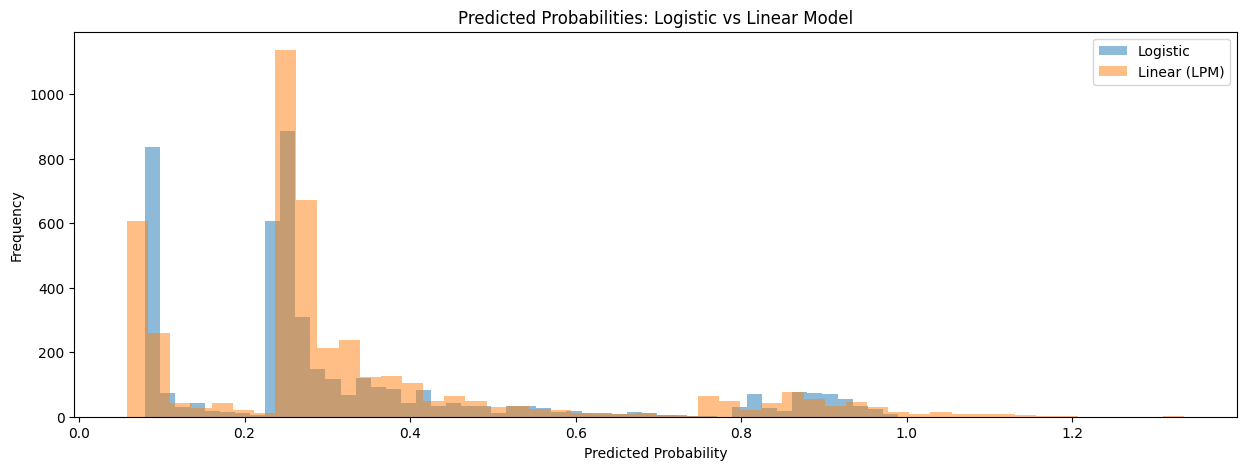

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.hist(df["log_pred"], bins=50, alpha=0.5, label="Logistic")
plt.hist(df["linear_pred"], bins=50, alpha=0.5, label="Linear (LPM)")

plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Predicted Probabilities: Logistic vs Linear Model")
plt.legend()
plt.show()

The logistic regression model produces probability values within the range of 0 to 1, while the linear model generates values outside this range, with probabilities greater than 1. This demonstrates that the linear model can produce invalid predictions, whereas logistic regression provides more appropriate and reliable probability estimates.

6. Students most at risk of dropping out are those with outstanding debt, those not up to date on tuition, those without scholarships, and older students. The strongest predictor is being up to date on tuition, as it significantly reduces dropout probability. Interventions such as financial aid, payment plans, and increased scholarship opportunities could help reduce dropout rates among these students.

In [ ]:
from sklearn.linear_model import LogisticRegression

y_multi = df["Target"]

X_multi = df[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]

mnl = LogisticRegression(multi_class="multinomial", max_iter=1000)
mnl.fit(X_multi, y_multi)

mnl_coef = pd.DataFrame(mnl.coef_)
mnl_coef = mnl_coef.set_axis(mnl.feature_names_in_, axis=1)

print("Coefficients for each class:")
mnl_coef

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Coefficients for each class:


,Debtor,Tuition fees up to date,Curricular units 1st sem (approved)
0,0.368317,-1.745175,-0.288982
1,0.272274,0.222429,-0.025552
2,-0.640591,1.522746,0.314533


In [ ]:
import numpy as np

y_class_multi = pd.Series(mnl.predict(X_multi))

tab_multi = pd.crosstab(y_class_multi, y_multi)

acc_multi = np.trace(tab_multi) / len(y_class_multi)

print(f"Confusion matrix:\n{tab_multi}")
print(f"\nAccuracy: {acc_multi}")

Confusion matrix:
Target    Dropout  Enrolled  Graduate
row_0                                
Dropout      1054       280       146
Graduate      367       514      2063

Accuracy: 0.35443037974683544


In [ ]:
probs = mnl.predict_proba(X_multi)

probs_df = pd.DataFrame(probs, columns=mnl.classes_)
probs_df.head()

,Dropout,Enrolled,Graduate
0,0.680547,0.210464,0.108989
1,0.695414,0.146043,0.158543
2,0.952988,0.041199,0.005813
3,0.117808,0.176983,0.705209
4,0.184227,0.212669,0.603104


The multinomial logistic regression model produces a confusion matrix for the three classes, but performance is uneven, with an overall accuracy of approximately 0.354. The hard classification does not predict every class, as the Enrolled category is never selected. However, the predicted probabilities assign values to all three classes for each observation, so every class is represented in the probability outputs.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [ ]:
import pandas as pd

df = pd.read_csv("cirrhosis.csv")

cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
df = df[cols]

print(df.isna().sum())

df = df.dropna()

df.head()

Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64


,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL


Again, removed any rows with missing values

In [ ]:
df["Edema"] = df["Edema"].map({
    "N": 0,
    "S": 1,
    "Y": 2
})

df["Drug"] = df["Drug"].map({
    "D-penicillamine": 1,
    "Placebo": 0
})

df["Status_binary"] = df["Status"].apply(lambda x: 1 if x == "D" else 0)

In [ ]:
from sklearn.linear_model import LogisticRegression

X = df[["Edema", "Drug", "Bilirubin"]]
y = df["Status_binary"]

model = LogisticRegression()
model.fit(X, y)

# Coefficients
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_[0]
})

print(coef_df)

    Variable  Coefficient
0      Edema     0.915295
1       Drug     0.223469
2  Bilirubin     0.348584


The drug does not improve survival probability, as its positive coefficient indicates an increased probability of death. Higher bilirubin levels are associated with lower survival, as bilirubin has a positive coefficient. Similarly, edema has the strongest positive effect on death out of the 3, indicating that higher levels of edema correspond to worse survival outcomes.

In [ ]:
p_death = model.predict_proba(X)[:,1]

df["survival_prob"] = 1 - p_death

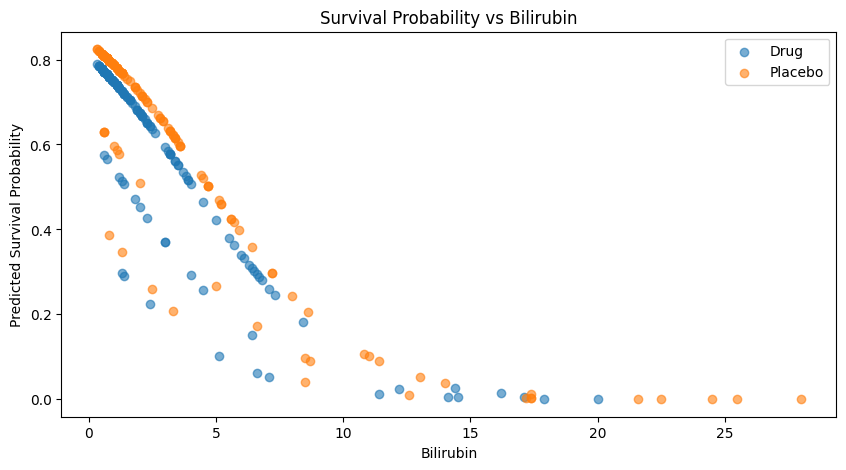

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for val in df["Drug"].unique():
    subset = df[df["Drug"] == val]
    label = "Drug" if val == 1 else "Placebo"

    plt.scatter(subset["Bilirubin"], subset["survival_prob"],
                label=label, alpha=0.6)

plt.xlabel("Bilirubin")
plt.ylabel("Predicted Survival Probability")
plt.title("Survival Probability vs Bilirubin")
plt.legend()
plt.show()

In [ ]:
X_drug = X.copy()
X_no_drug = X.copy()

X_drug["Drug"] = 1
X_no_drug["Drug"] = 0

surv_drug = 1 - model.predict_proba(X_drug)[:,1]
surv_no = 1 - model.predict_proba(X_no_drug)[:,1]

df["drug_effect"] = surv_drug - surv_no

In [ ]:
avg_effect = df["drug_effect"].mean()
print(avg_effect)

-0.040407263046261875


The scatter plot shows that survival probability decreases as bilirubin increases. The drug does not increase survival at any level of bilirubin. On average, taking the drug reduces survival probability by approximately 0.040.

In [ ]:
import numpy as np

y_class = pd.Series(model.predict(X))

tab = pd.crosstab(y_class, y)

acc = np.trace(tab) / len(y_class)

print(f"Confusion matrix:\n{tab}")
print(f"\nAccuracy: {acc}")

Confusion matrix:
Status_binary    0   1
row_0                 
0              173  65
1               14  60

Accuracy: 0.7467948717948718


In [ ]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)

df["lin_death"] = lin_model.predict(X)

df["lin_survival"] = 1 - df["lin_death"]

df["logit_survival"] = 1 - model.predict_proba(X)[:,1]

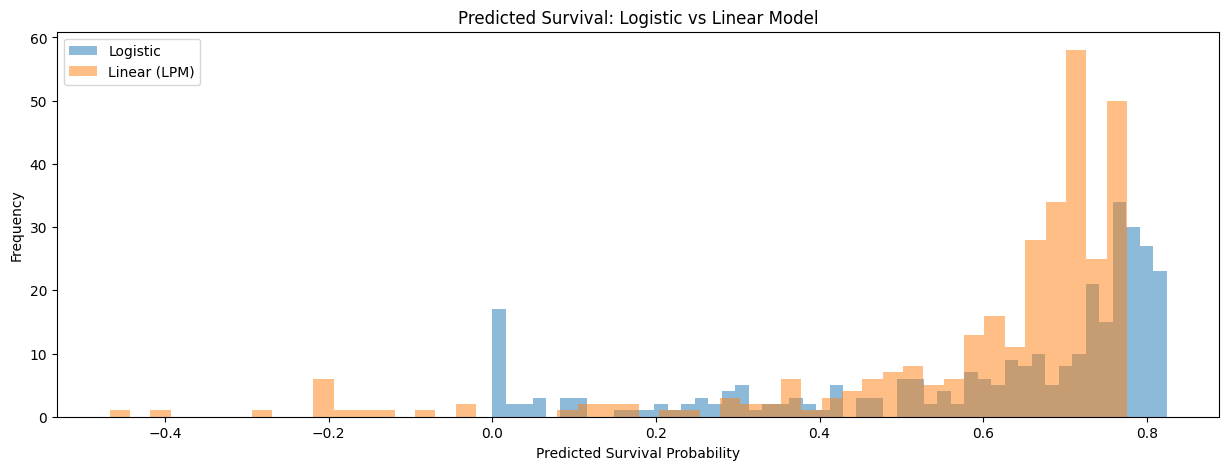

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.hist(df["logit_survival"], bins=50, alpha=0.5, label="Logistic")
plt.hist(df["lin_survival"], bins=50, alpha=0.5, label="Linear (LPM)")

plt.xlabel("Predicted Survival Probability")
plt.ylabel("Frequency")
plt.title("Predicted Survival: Logistic vs Linear Model")
plt.legend()
plt.show()

Again, the logistic regression model produces probability values within the range of 0 to 1, while the linear model generates values outside this range, with negative probabilities. This demonstrates that the linear model can produce invalid predictions, whereas logistic regression provides more appropriate and reliable probability estimates.

In [ ]:
from sklearn.linear_model import LogisticRegression

y_stage = df["Stage"]

X_stage = df[["Edema", "Bilirubin"]]

In [ ]:
stage_model = LogisticRegression(multi_class="multinomial", max_iter=1000)
stage_model.fit(X_stage, y_stage)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [ ]:
import numpy as np

y_class_stage = pd.Series(stage_model.predict(X_stage))

tab_stage = pd.crosstab(y_class_stage, y_stage)

acc_stage = np.trace(tab_stage) / len(y_class_stage)

print(f"Confusion matrix:\n{tab_stage}")
print(f"\nAccuracy: {acc_stage}")

Confusion matrix:
Stage  1.0  2.0  3.0  4.0
row_0                    
3.0     16   61  102   74
4.0      0    6   18   35

Accuracy: 0.07051282051282051


In [ ]:
probs_stage = stage_model.predict_proba(X_stage)

probs_df_stage = pd.DataFrame(probs_stage, columns=stage_model.classes_)
probs_df_stage.head()

,1.0,2.0,3.0,4.0
0,0.000004,0.026212,0.163753,0.810031
1,0.073533,0.252875,0.400994,0.272598
2,0.026874,0.172054,0.337700,0.463372
3,0.021408,0.167391,0.338390,0.472811
4,0.020987,0.227850,0.428140,0.323023


The multinomial logistic regression model performs poorly, with an accuracy of approximately 0.071. The hard classification does not predict every class, as stages 1 and 2 are never selected. However, the predicted probabilities assign values to all four stages for each observation, so every class is represented in the probability outputs.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

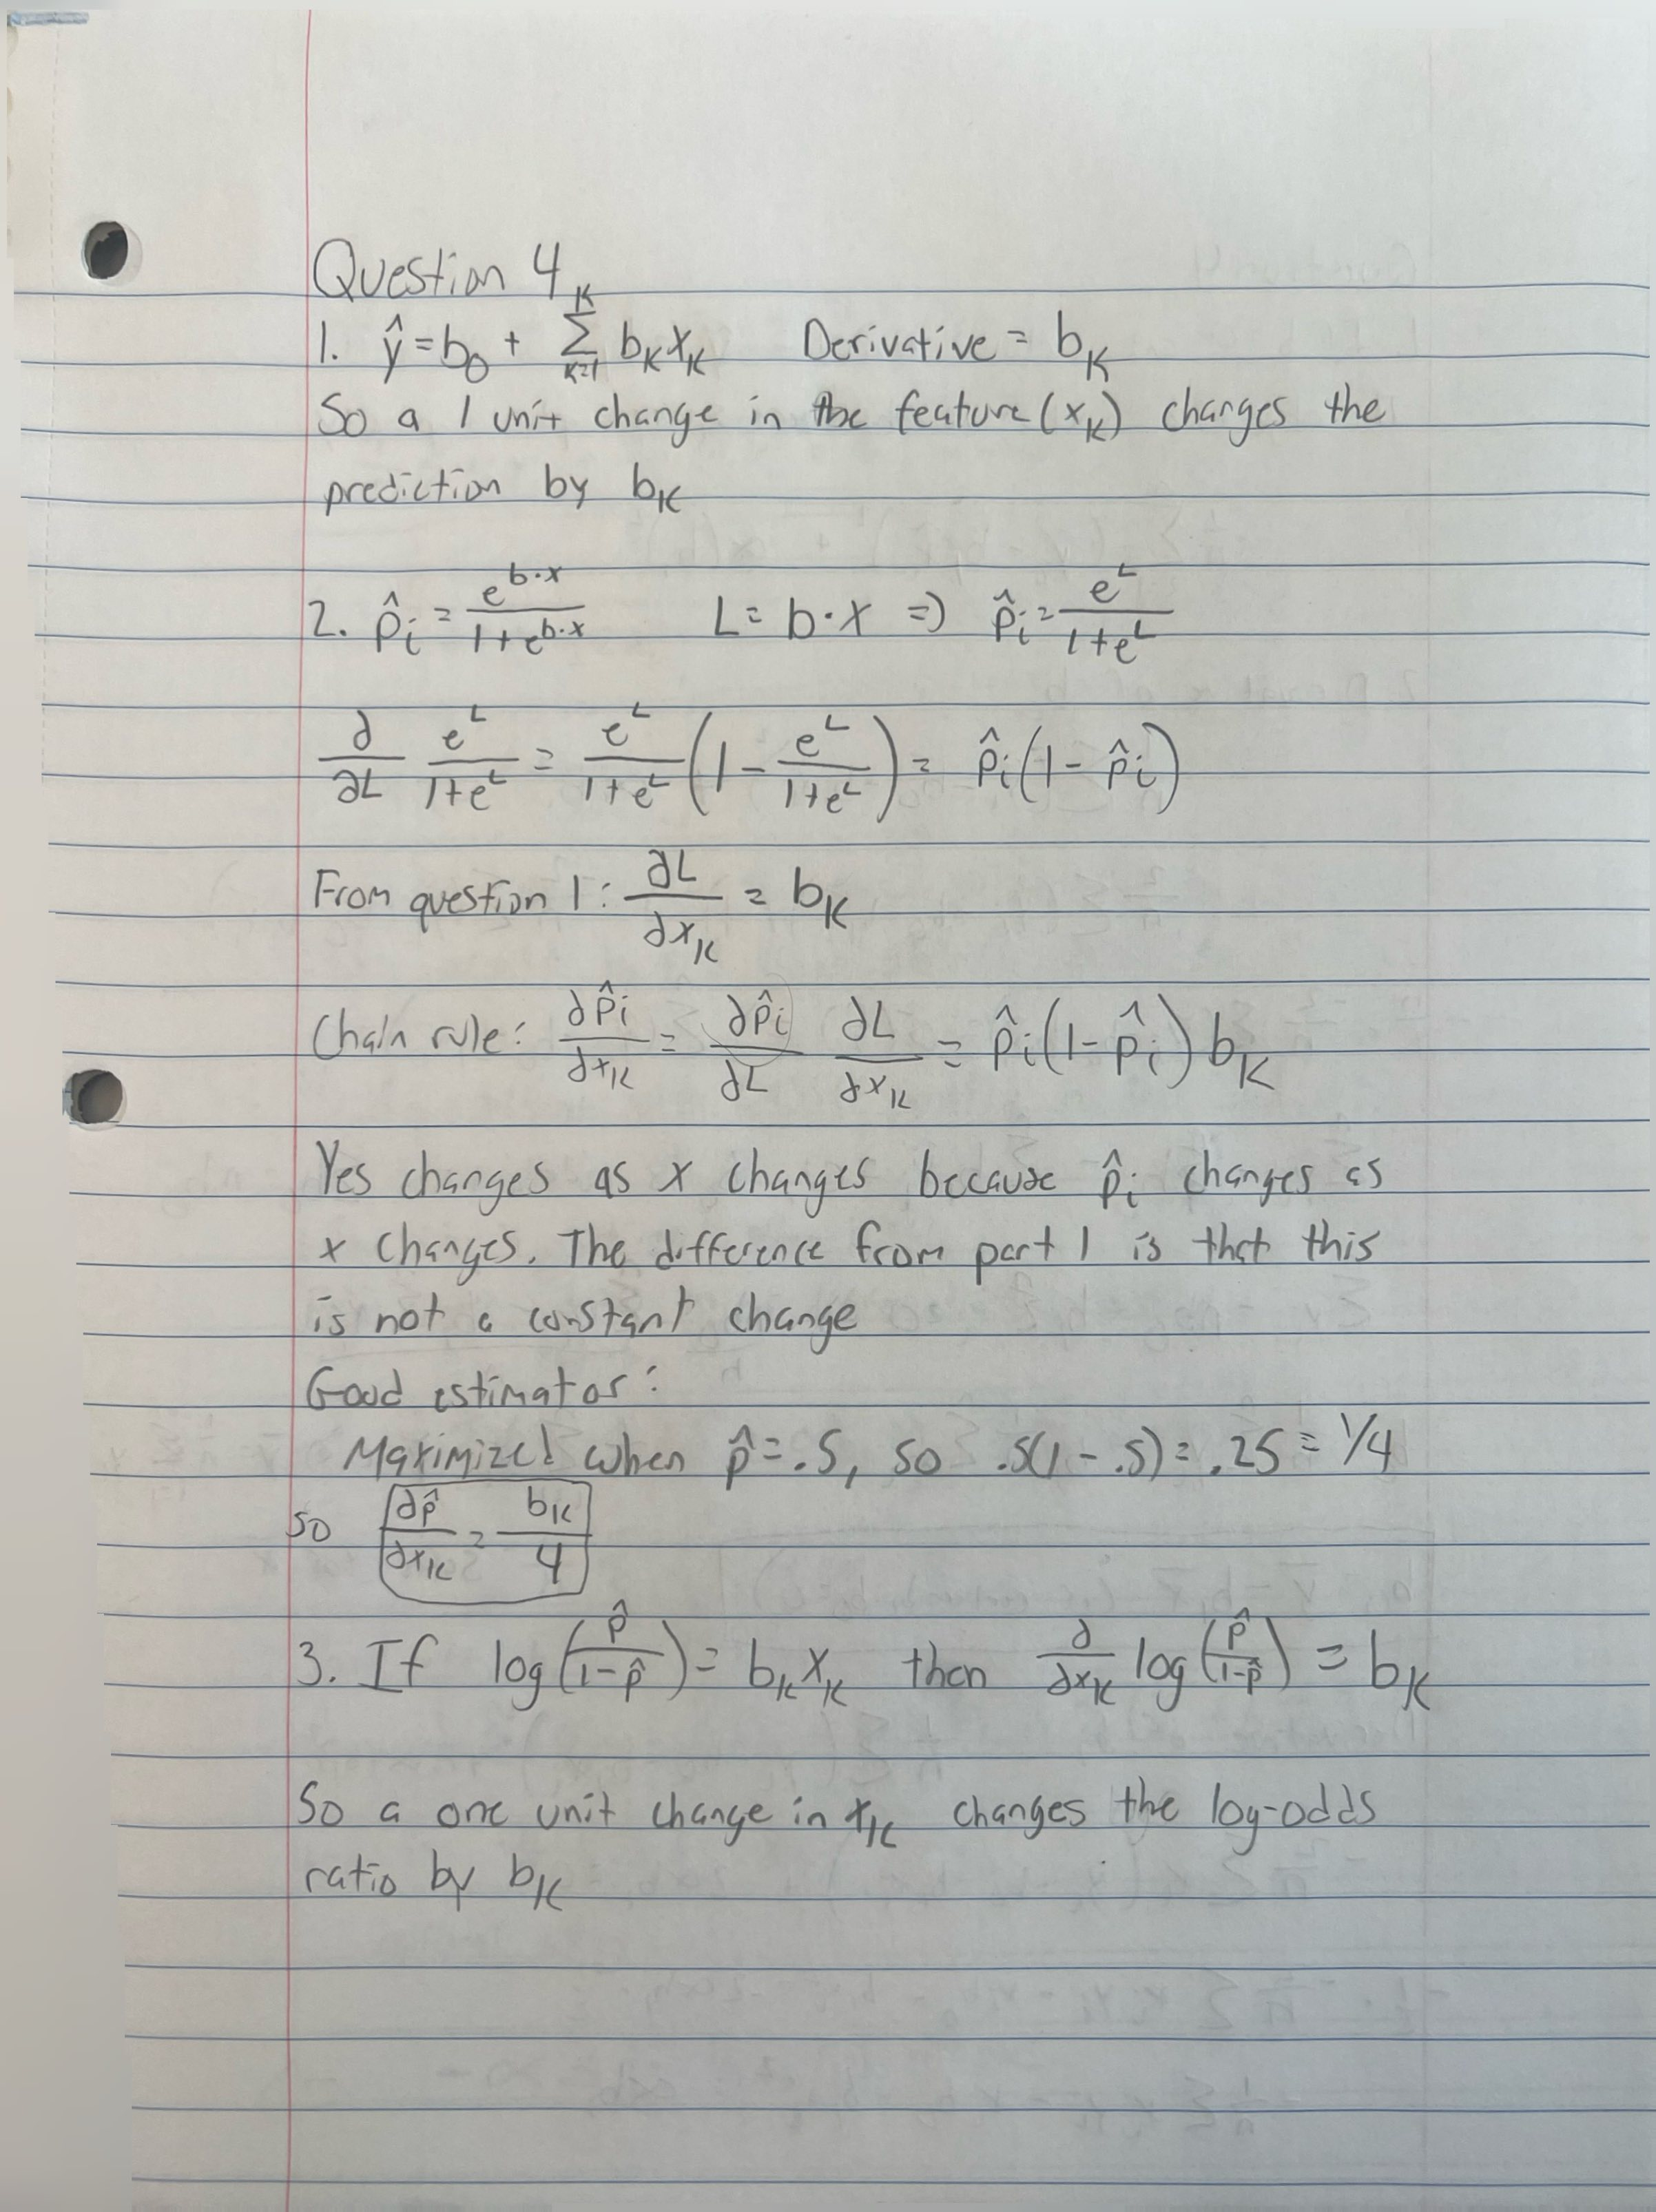